# Flood Forecasting Model — All Features

This notebook trains flood/water-level forecasting models using:

- current `water_level`
- engineered water-level lag/rolling/change/slope features
- `reservoir_volume`
- engineered reservoir-volume lag/rolling/change/slope features
- time/calendar features

It also fixes the horizon bug by converting real hours into row periods using the detected timestamp frequency.

In [42]:
# ============================================================
# 1. Imports
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
import joblib

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)

In [43]:
# ============================================================
# 2. Configuration
# ============================================================

DATE_COL = "timestamp"
TARGET_COL = "water_level"
RESERVOIR_COL = "reservoir_volume"

# The notebook tries these paths in order.
DATA_PATH_CANDIDATES = [
    "../src/data/processed/nve_observations_wide_clean.csv",



]

HORIZONS = [6, 24, 72]

# These are real hours, not row counts.
LAGS = [1, 3, 6, 12, 24, 48, 72]
ROLLING_WINDOWS = [3, 6, 12, 24, 48, 72]

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

FLOOD_QUANTILE = 0.90
RANDOM_STATE = 42

OUTPUT_DIR_CANDIDATES = [ "../src/data/processed"]
MODEL_DIR_CANDIDATES = ["../models"]

In [44]:
# ============================================================
# 3. Helper functions for paths and loading
# ============================================================

def first_existing_path(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None


def first_creatable_dir(paths):
    for p in paths:
        try:
            os.makedirs(p, exist_ok=True)
            return p
        except Exception:
            continue
    raise OSError(f"Could not create any of these directories: {paths}")


OUTPUT_DIR = first_creatable_dir(OUTPUT_DIR_CANDIDATES)
MODEL_DIR = first_creatable_dir(MODEL_DIR_CANDIDATES)

print("OUTPUT_DIR:", OUTPUT_DIR)
print("MODEL_DIR:", MODEL_DIR)


def load_nve_dataframe():
    data_path = first_existing_path(DATA_PATH_CANDIDATES)

    if data_path is None:
        raise FileNotFoundError(
            "No input file found. Expected one of:\n" + "\n".join(DATA_PATH_CANDIDATES)
        )

    print("Loading:", data_path)
    raw = pd.read_csv(data_path)

    # If long format, pivot to wide.
    if {"feature_name", "value", DATE_COL}.issubset(raw.columns):
        print("Detected long format. Pivoting to wide format.")
        data = (
            raw
            .pivot_table(
                index=DATE_COL,
                columns="feature_name",
                values="value",
                aggfunc="mean"
            )
            .reset_index()
            .sort_values(DATE_COL)
        )
        data.columns.name = None
    else:
        data = raw.copy()
        data.columns.name = None

    return data, data_path

OUTPUT_DIR: ../src/data/processed
MODEL_DIR: ../models


In [45]:
# ============================================================
# 4. Load and clean data
# ============================================================

df, DATA_PATH = load_nve_dataframe()

if DATE_COL not in df.columns:
    raise ValueError(f"Missing {DATE_COL}. Available columns: {df.columns.tolist()}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", utc=True)
df = df.dropna(subset=[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

# Drop metadata columns if present.
metadata_cols = [
    "station_id", "stationId", "parameter", "resolution_time",
    "feature_name", "unit", "quality"
]
df = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors="ignore")

# Convert non-date columns to numeric.
for col in df.columns:
    if col != DATE_COL:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if TARGET_COL not in df.columns:
    raise ValueError(f"Missing required target column '{TARGET_COL}'. Available columns: {df.columns.tolist()}")

if RESERVOIR_COL not in df.columns:
    print(f"WARNING: '{RESERVOIR_COL}' is missing. The notebook will train water-level-only features.")
    print("To include reservoir volume, download NVE parameter 1004 and load the wide CSV.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Remove columns that are still completely missing.
all_nan_cols = [c for c in df.columns if c != DATE_COL and df[c].isna().all()]
df = df.drop(columns=all_nan_cols)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())
display(df.head())
display(df.describe().T)

Loading: ../src/data/processed/nve_observations_wide_clean.csv
Shape: (42776, 3)
Columns: ['timestamp', 'reservoir_volume', 'water_level']
Date range: 2020-12-13 12:00:00+00:00 to 2026-01-01 00:00:00+00:00


,timestamp,reservoir_volume,water_level
0,2020-12-13 12:00:00+00:00,9.220051,79.12000
1,2020-12-13 13:00:00+00:00,9.233793,79.12125
2,2020-12-13 14:00:00+00:00,9.316249,79.12875
3,2020-12-13 15:00:00+00:00,9.329991,79.13000
4,2020-12-13 16:00:00+00:00,9.343745,79.13125


,count,mean,std,min,25%,50%,75%,max
reservoir_volume,42776.0,6.772088,2.203438,-0.277565,5.036248,6.700681,8.534985,13.51003
water_level,42776.0,78.904336,0.196792,78.272490,78.748750,78.900065,79.061250,79.51000


In [46]:
# ============================================================
# 5. Detect time frequency and horizon conversion
# ============================================================

time_diffs = df[DATE_COL].diff().dropna()
time_step_hours = time_diffs.median().total_seconds() / 3600

if not np.isfinite(time_step_hours) or time_step_hours <= 0:
    raise ValueError("Could not detect a valid time step from timestamps.")

print("Detected median time step:", time_step_hours, "hours")
display(time_diffs.value_counts().head(10))


def hours_to_periods(hours):
    """Convert real hours into dataframe row periods."""
    return max(int(round(hours / time_step_hours)), 1)


print("Horizon conversion:")
for h in HORIZONS:
    print(f"{h}h -> shift({hours_to_periods(h)}) rows")

print("Lag conversion:")
for lag in LAGS:
    print(f"{lag}h -> shift({hours_to_periods(lag)}) rows")

Detected median time step: 1.0 hours


timestamp
0 days 01:00:00    42740
0 days 04:00:00       14
0 days 06:00:00        3
0 days 05:00:00        2
0 days 07:00:00        2
1 days 08:00:00        1
1 days 00:00:00        1
0 days 11:00:00        1
0 days 16:00:00        1
3 days 00:00:00        1
Name: count, dtype: int64

Horizon conversion:
6h -> shift(6) rows
24h -> shift(24) rows
72h -> shift(72) rows
Lag conversion:
1h -> shift(1) rows
3h -> shift(3) rows
6h -> shift(6) rows
12h -> shift(12) rows
24h -> shift(24) rows
48h -> shift(48) rows
72h -> shift(72) rows


In [47]:
# ============================================================
# 6. Feature engineering
# ============================================================

def add_time_features(data, date_col):
    data = data.copy()
    dt = pd.to_datetime(data[date_col])

    data["hour"] = dt.dt.hour
    data["dayofyear"] = dt.dt.dayofyear
    data["month"] = dt.dt.month
    data["dayofweek"] = dt.dt.dayofweek
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

    data["sin_hour"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["cos_hour"] = np.cos(2 * np.pi * data["hour"] / 24)

    data["sin_dayofyear"] = np.sin(2 * np.pi * data["dayofyear"] / 365)
    data["cos_dayofyear"] = np.cos(2 * np.pi * data["dayofyear"] / 365)

    data["sin_month"] = np.sin(2 * np.pi * data["month"] / 12)
    data["cos_month"] = np.cos(2 * np.pi * data["month"] / 12)

    return data


def add_lag_rolling_change_features(data, base_cols):
    """Add lag, rolling, change, and slope features for each numeric base column."""
    data = data.copy()

    for base_col in base_cols:
        if base_col not in data.columns:
            print(f"Skipping missing base column: {base_col}")
            continue

        print(f"Engineering features for: {base_col}")

        # Lags.
        for lag in LAGS:
            periods = hours_to_periods(lag)
            lag_col = f"{base_col}_lag_{lag}h"
            if lag_col not in data.columns:
                data[lag_col] = data[base_col].shift(periods)

        # Rolling windows.
        for w in ROLLING_WINDOWS:
            periods = hours_to_periods(w)

            mean_col = f"{base_col}_roll_mean_{w}h"
            std_col = f"{base_col}_roll_std_{w}h"
            min_col = f"{base_col}_roll_min_{w}h"
            max_col = f"{base_col}_roll_max_{w}h"

            if mean_col not in data.columns:
                data[mean_col] = data[base_col].rolling(periods).mean()
            if std_col not in data.columns:
                data[std_col] = data[base_col].rolling(periods).std()
            if min_col not in data.columns:
                data[min_col] = data[base_col].rolling(periods).min()
            if max_col not in data.columns:
                data[max_col] = data[base_col].rolling(periods).max()

        # Change and slope.
        for lag in LAGS:
            lag_col = f"{base_col}_lag_{lag}h"
            change_col = f"{base_col}_change_{lag}h"
            slope_col = f"{base_col}_slope_{lag}h"

            if lag_col in data.columns:
                if change_col not in data.columns:
                    data[change_col] = data[base_col] - data[lag_col]
                if slope_col not in data.columns:
                    data[slope_col] = data[change_col] / lag

    return data


# Base numeric features available before engineering.
base_numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns.tolist()
    if c != DATE_COL
]

# Ensure target first, reservoir second if present.
ordered_base_cols = []
for c in [TARGET_COL, RESERVOIR_COL]:
    if c in base_numeric_cols and c not in ordered_base_cols:
        ordered_base_cols.append(c)

for c in base_numeric_cols:
    if c not in ordered_base_cols:
        ordered_base_cols.append(c)

print("Base columns used for feature engineering:", ordered_base_cols)

df_feat = add_time_features(df, DATE_COL)
df_feat = add_lag_rolling_change_features(df_feat, ordered_base_cols)

print("Shape after feature engineering:", df_feat.shape)
display(df_feat.head())

Base columns used for feature engineering: ['water_level', 'reservoir_volume']
Engineering features for: water_level
Engineering features for: reservoir_volume
Shape after feature engineering: (42776, 104)


,timestamp,reservoir_volume,water_level,hour,dayofyear,month,dayofweek,is_weekend,sin_hour,cos_hour,sin_dayofyear,cos_dayofyear,sin_month,cos_month,water_level_lag_1h,water_level_lag_3h,water_level_lag_6h,water_level_lag_12h,water_level_lag_24h,water_level_lag_48h,water_level_lag_72h,water_level_roll_mean_3h,water_level_roll_std_3h,water_level_roll_min_3h,water_level_roll_max_3h,water_level_roll_mean_6h,water_level_roll_std_6h,water_level_roll_min_6h,water_level_roll_max_6h,water_level_roll_mean_12h,water_level_roll_std_12h,water_level_roll_min_12h,water_level_roll_max_12h,water_level_roll_mean_24h,water_level_roll_std_24h,water_level_roll_min_24h,water_level_roll_max_24h,water_level_roll_mean_48h,water_level_roll_std_48h,water_level_roll_min_48h,water_level_roll_max_48h,water_level_roll_mean_72h,water_level_roll_std_72h,water_level_roll_min_72h,water_level_roll_max_72h,water_level_change_1h,water_level_slope_1h,water_level_change_3h,water_level_slope_3h,water_level_change_6h,water_level_slope_6h,water_level_change_12h,water_level_slope_12h,water_level_change_24h,water_level_slope_24h,water_level_change_48h,water_level_slope_48h,water_level_change_72h,water_level_slope_72h,reservoir_volume_lag_1h,reservoir_volume_lag_3h,reservoir_volume_lag_6h,reservoir_volume_lag_12h,reservoir_volume_lag_24h,reservoir_volume_lag_48h,reservoir_volume_lag_72h,reservoir_volume_roll_mean_3h,reservoir_volume_roll_std_3h,reservoir_volume_roll_min_3h,reservoir_volume_roll_max_3h,reservoir_volume_roll_mean_6h,reservoir_volume_roll_std_6h,reservoir_volume_roll_min_6h,reservoir_volume_roll_max_6h,reservoir_volume_roll_mean_12h,reservoir_volume_roll_std_12h,reservoir_volume_roll_min_12h,reservoir_volume_roll_max_12h,reservoir_volume_roll_mean_24h,reservoir_volume_roll_std_24h,reservoir_volume_roll_min_24h,reservoir_volume_roll_max_24h,reservoir_volume_roll_mean_48h,reservoir_volume_roll_std_48h,reservoir_volume_roll_min_48h,reservoir_volume_roll_max_48h,reservoir_volume_roll_mean_72h,reservoir_volume_roll_std_72h,reservoir_volume_roll_min_72h,reservoir_volume_roll_max_72h,reservoir_volume_change_1h,reservoir_volume_slope_1h,reservoir_volume_change_3h,reservoir_volume_slope_3h,reservoir_volume_change_6h,reservoir_volume_slope_6h,reservoir_volume_change_12h,reservoir_volume_slope_12h,reservoir_volume_change_24h,reservoir_volume_slope_24h,reservoir_volume_change_48h,reservoir_volume_slope_48h,reservoir_volume_change_72h,reservoir_volume_slope_72h
0,2020-12-13 12:00:00+00:00,9.220051,79.12000,12,348,12,6,1,1.224647e-16,-1.000000,-0.288482,0.957485,-2.449294e-16,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-12-13 13:00:00+00:00,9.233793,79.12125,13,348,12,6,1,-2.588190e-01,-0.965926,-0.288482,0.957485,-2.449294e-16,1.0,79.12000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00125,0.00125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.220051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013742,0.013742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-12-13 14:00:00+00:00,9.316249,79.12875,14,348,12,6,1,-5.000000e-01,-0.866025,-0.288482,0.957485,-2.449294e-16,1.0,79.12125,NaN,NaN,NaN,NaN,NaN,NaN,79.123333,0.004732,79.12000,79.12875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00750,0.00750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.233793,NaN,NaN,NaN,NaN,NaN,NaN,9.256698,0.052029,9.220051,9.316249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.082456,0.082456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# ============================================================
# 7. Create future targets and delta targets
# ============================================================

df_model = df_feat.copy()

TARGETS = []
DELTA_TARGETS = {}

for h in HORIZONS:
    periods = hours_to_periods(h)

    target_name = f"target_{h}h"
    delta_name = f"delta_{h}h"

    df_model[target_name] = df_model[TARGET_COL].shift(-periods)
    df_model[delta_name] = df_model[target_name] - df_model[TARGET_COL]

    TARGETS.append(target_name)
    DELTA_TARGETS[delta_name] = target_name

# Drop rows where target columns are missing. Do not drop all feature NaNs globally yet.
required_target_cols = [TARGET_COL] + TARGETS + list(DELTA_TARGETS.keys())
df_model = df_model.dropna(subset=required_target_cols).reset_index(drop=True)

print("Final model shape before feature-specific NaN filtering:", df_model.shape)
print("Targets:", TARGETS)
print("Delta targets:", DELTA_TARGETS)

display(df_model[[DATE_COL, TARGET_COL] + TARGETS + list(DELTA_TARGETS.keys())].head())
display(df_model.isna().sum().sort_values(ascending=False).head(20))

Final model shape before feature-specific NaN filtering: (42704, 110)
Targets: ['target_6h', 'target_24h', 'target_72h']
Delta targets: {'delta_6h': 'target_6h', 'delta_24h': 'target_24h', 'delta_72h': 'target_72h'}


,timestamp,water_level,target_6h,target_24h,target_72h,delta_6h,delta_24h,delta_72h
0,2020-12-13 12:00:00+00:00,79.12000,79.14000,79.16875,79.05874,0.02000,0.04875,-0.06126
1,2020-12-13 13:00:00+00:00,79.12125,79.14000,79.16125,79.05125,0.01875,0.04000,-0.07000
2,2020-12-13 14:00:00+00:00,79.12875,79.14125,79.15750,79.05000,0.01250,0.02875,-0.07875
3,2020-12-13 15:00:00+00:00,79.13000,79.14876,79.14500,79.04874,0.01876,0.01500,-0.08126
4,2020-12-13 16:00:00+00:00,79.13125,79.15000,79.15750,79.04124,0.01875,0.02625,-0.09001


reservoir_volume_change_72h       72
water_level_slope_72h             72
water_level_change_72h            72
reservoir_volume_lag_72h          72
reservoir_volume_slope_72h        72
water_level_lag_72h               72
reservoir_volume_roll_mean_72h    71
reservoir_volume_roll_std_72h     71
reservoir_volume_roll_min_72h     71
water_level_roll_max_72h          71
water_level_roll_min_72h          71
water_level_roll_std_72h          71
water_level_roll_mean_72h         71
reservoir_volume_roll_max_72h     71
water_level_lag_48h               48
reservoir_volume_lag_48h          48
water_level_change_48h            48
water_level_slope_48h             48
reservoir_volume_slope_48h        48
reservoir_volume_change_48h       48
dtype: int64

In [49]:
# ============================================================
# 8. Select modelling features
# ============================================================

exclude_cols = set([DATE_COL] + TARGETS + list(DELTA_TARGETS.keys()))

FEATURES = [
    col for col in df_model.columns
    if col not in exclude_cols
    and pd.api.types.is_numeric_dtype(df_model[col])
]

# Drop constant or all-missing feature columns.
good_features = []
for col in FEATURES:
    if df_model[col].notna().sum() == 0:
        continue
    if df_model[col].nunique(dropna=True) <= 1:
        continue
    good_features.append(col)

FEATURES = good_features

print("Number of features:", len(FEATURES))
print("First 80 features:")
print(FEATURES[:80])

reservoir_features = [c for c in FEATURES if RESERVOIR_COL in c]
print("\nReservoir-related feature count:", len(reservoir_features))
print(reservoir_features[:40])

Number of features: 103
First 80 features:
['reservoir_volume', 'water_level', 'hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'sin_hour', 'cos_hour', 'sin_dayofyear', 'cos_dayofyear', 'sin_month', 'cos_month', 'water_level_lag_1h', 'water_level_lag_3h', 'water_level_lag_6h', 'water_level_lag_12h', 'water_level_lag_24h', 'water_level_lag_48h', 'water_level_lag_72h', 'water_level_roll_mean_3h', 'water_level_roll_std_3h', 'water_level_roll_min_3h', 'water_level_roll_max_3h', 'water_level_roll_mean_6h', 'water_level_roll_std_6h', 'water_level_roll_min_6h', 'water_level_roll_max_6h', 'water_level_roll_mean_12h', 'water_level_roll_std_12h', 'water_level_roll_min_12h', 'water_level_roll_max_12h', 'water_level_roll_mean_24h', 'water_level_roll_std_24h', 'water_level_roll_min_24h', 'water_level_roll_max_24h', 'water_level_roll_mean_48h', 'water_level_roll_std_48h', 'water_level_roll_min_48h', 'water_level_roll_max_48h', 'water_level_roll_mean_72h', 'water_level_roll_std_72h', 'water_l

In [50]:
# ============================================================
# 9. Split helper and evaluation functions
# ============================================================

def time_split(data, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    data = data.sort_values(DATE_COL).reset_index(drop=True)
    n = len(data)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train = data.iloc[:train_end].copy()
    val = data.iloc[train_end:val_end].copy()
    test = data.iloc[val_end:].copy()

    return train, val, test


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def flood_metrics(y_true, y_pred, threshold):
    y_true_flood = (np.asarray(y_true) >= threshold).astype(int)
    y_pred_flood = (np.asarray(y_pred) >= threshold).astype(int)

    precision = precision_score(y_true_flood, y_pred_flood, zero_division=0)
    recall = recall_score(y_true_flood, y_pred_flood, zero_division=0)
    f1 = f1_score(y_true_flood, y_pred_flood, zero_division=0)

    cm = confusion_matrix(y_true_flood, y_pred_flood, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "Flood_Precision": precision,
        "Flood_Recall": recall,
        "Flood_F1": f1,
        "False_Alarms": fp,
        "Missed_Floods": fn,
        "Detected_Floods": tp,
        "True_NonFloods": tn,
    }


def evaluate_prediction(y_true, y_pred, model_name, horizon, threshold):
    if len(y_true) == 0 or len(y_pred) == 0:
        raise ValueError(f"No samples available for evaluation: {model_name}, {horizon}h")

    reg = regression_metrics(y_true, y_pred)
    flood = flood_metrics(y_true, y_pred, threshold)

    row = {
        "model": model_name,
        "horizon": f"target_{horizon}h",
        **reg,
        **flood,
    }

    print(f"\n{model_name} | {horizon}h")
    print("MAE :", round(row["MAE"], 5))
    print("RMSE:", round(row["RMSE"], 5))
    print("R2  :", round(row["R2"], 5))
    print("Flood F1:", round(row["Flood_F1"], 5))

    return row

In [51]:
# ============================================================
# 10. Baselines and model factory
# ============================================================

def persistence_prediction(data):
    return data[TARGET_COL].to_numpy()


def seasonal_persistence_prediction(data, season_lag=24):
    lag_col = f"{TARGET_COL}_lag_{season_lag}h"
    if lag_col in data.columns:
        return data[lag_col].to_numpy()
    return data[TARGET_COL].to_numpy()


def rolling_mean_prediction(data, window=24):
    roll_col = f"{TARGET_COL}_roll_mean_{window}h"
    if roll_col in data.columns:
        return data[roll_col].to_numpy()
    return data[TARGET_COL].to_numpy()


def make_xgb_model(horizon):
    if XGBOOST_AVAILABLE:
        if horizon <= 6:
            return XGBRegressor(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.5,
                reg_lambda=2.0,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )

        return XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.02,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.2,
            reg_lambda=1.5,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    return HistGradientBoostingRegressor(
        max_iter=300 if horizon <= 6 else 500,
        learning_rate=0.03 if horizon <= 6 else 0.02,
        max_leaf_nodes=15 if horizon <= 6 else 31,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )


def make_ridge_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

In [52]:
# ============================================================
# 11. Train models horizon by horizon
# ============================================================

all_results = []
models = {}
predictions = {}
test_sets = {}
feature_sets = {}
flood_thresholds = {}

for h in HORIZONS:
    print("=" * 80)
    print(f"Horizon: {h}h")

    target = f"target_{h}h"
    delta_target = f"delta_{h}h"

    # Clean only the columns required for this horizon.
    horizon_cols = [DATE_COL] + FEATURES + [target, delta_target]
    model_data = df_model[horizon_cols].copy()
    model_data = model_data.dropna(subset=FEATURES + [target, delta_target]).reset_index(drop=True)

    print("Rows available after NaN filtering:", model_data.shape[0])

    if len(model_data) < 100:
        print(f"Skipping {h}h: not enough rows after filtering.")
        continue

    train, val, test = time_split(model_data)

    print("Train:", train[DATE_COL].min(), "to", train[DATE_COL].max(), train.shape)
    print("Val  :", val[DATE_COL].min(), "to", val[DATE_COL].max(), val.shape)
    print("Test :", test[DATE_COL].min(), "to", test[DATE_COL].max(), test.shape)

    if len(test) == 0:
        print(f"Skipping {h}h: test set is empty.")
        continue

    X_train = train[FEATURES]
    X_val = val[FEATURES]
    X_test = test[FEATURES]

    y_train = train[target].to_numpy()
    y_test = test[target].to_numpy()

    y_delta_train = train[delta_target].to_numpy()
    y_delta_test = test[delta_target].to_numpy()

    flood_threshold = train[target].quantile(FLOOD_QUANTILE)
    flood_thresholds[target] = flood_threshold

    test_sets[target] = test
    feature_sets[target] = FEATURES

    # --------------------------------------------------------
    # Baseline 1: persistence
    # --------------------------------------------------------
    pred_persistence = persistence_prediction(test)
    name = f"Baseline Persistence {target}"
    all_results.append(evaluate_prediction(y_test, pred_persistence, name, h, flood_threshold))
    predictions[name] = pred_persistence

    # --------------------------------------------------------
    # Baseline 2: seasonal persistence 24h
    # --------------------------------------------------------
    pred_seasonal = seasonal_persistence_prediction(test, season_lag=24)
    name = f"Baseline Seasonal24 {target}"
    all_results.append(evaluate_prediction(y_test, pred_seasonal, name, h, flood_threshold))
    predictions[name] = pred_seasonal

    # --------------------------------------------------------
    # Baseline 3: rolling mean 24h
    # --------------------------------------------------------
    pred_roll = rolling_mean_prediction(test, window=24)
    name = f"Baseline Rolling24 {target}"
    all_results.append(evaluate_prediction(y_test, pred_roll, name, h, flood_threshold))
    predictions[name] = pred_roll

    # --------------------------------------------------------
    # Ridge delta
    # --------------------------------------------------------
    ridge_delta = make_ridge_model()
    ridge_delta.fit(X_train, y_delta_train)

    pred_delta = ridge_delta.predict(X_test)
    pred_ridge_delta = test[TARGET_COL].to_numpy() + pred_delta

    name = f"Ridge Delta {target}"
    all_results.append(evaluate_prediction(y_test, pred_ridge_delta, name, h, flood_threshold))
    predictions[name] = pred_ridge_delta
    models[name] = ridge_delta

    # --------------------------------------------------------
    # Gradient/XGBoost absolute target
    # --------------------------------------------------------
    abs_model = make_xgb_model(h)
    abs_model.fit(X_train, y_train)

    pred_abs = abs_model.predict(X_test)

    name = f"{'XGBoost' if XGBOOST_AVAILABLE else 'HistGB'} Absolute {target}"
    all_results.append(evaluate_prediction(y_test, pred_abs, name, h, flood_threshold))
    predictions[name] = pred_abs
    models[name] = abs_model

    # --------------------------------------------------------
    # Gradient/XGBoost delta target
    # --------------------------------------------------------
    delta_model = make_xgb_model(h)
    delta_model.fit(X_train, y_delta_train)

    pred_delta = delta_model.predict(X_test)
    pred_delta_level = test[TARGET_COL].to_numpy() + pred_delta

    name = f"{'XGBoost' if XGBOOST_AVAILABLE else 'HistGB'} Delta {target}"
    all_results.append(evaluate_prediction(y_test, pred_delta_level, name, h, flood_threshold))
    predictions[name] = pred_delta_level
    models[name] = delta_model

results_df = pd.DataFrame(all_results)
display(results_df)

Horizon: 6h
Rows available after NaN filtering: 42632
Train: 2020-12-16 12:00:00+00:00 to 2024-07-09 21:00:00+00:00 (29842, 106)
Val  : 2024-07-09 22:00:00+00:00 to 2025-04-03 05:00:00+00:00 (6395, 106)
Test : 2025-04-03 06:00:00+00:00 to 2025-12-29 00:00:00+00:00 (6395, 106)

Baseline Persistence target_6h | 6h
MAE : 0.00709
RMSE: 0.01055
R2  : 0.99439
Flood F1: 0.95854

Baseline Seasonal24 target_6h | 6h
MAE : 0.02634
RMSE: 0.03731
R2  : 0.92976
Flood F1: 0.84847

Baseline Rolling24 target_6h | 6h
MAE : 0.01602
RMSE: 0.02321
R2  : 0.9728
Flood F1: 0.90657

Ridge Delta target_6h | 6h
MAE : 0.00697
RMSE: 0.01042
R2  : 0.99452
Flood F1: 0.95277

XGBoost Absolute target_6h | 6h
MAE : 0.00704
RMSE: 0.01041
R2  : 0.99453
Flood F1: 0.95624

XGBoost Delta target_6h | 6h
MAE : 0.00638
RMSE: 0.00978
R2  : 0.99517
Flood F1: 0.96173
Horizon: 24h
Rows available after NaN filtering: 42632
Train: 2020-12-16 12:00:00+00:00 to 2024-07-09 21:00:00+00:00 (29842, 106)
Val  : 2024-07-09 22:00:00+00:00 to

,model,horizon,MAE,RMSE,R2,Flood_Precision,Flood_Recall,Flood_F1,False_Alarms,Missed_Floods,Detected_Floods,True_NonFloods
0,Baseline Persistence target_6h,target_6h,0.007085,0.010548,0.994386,0.958539,0.958539,0.958539,84,84,1942,4285
1,Baseline Seasonal24 target_6h,target_6h,0.026343,0.037309,0.929758,0.848470,0.848470,0.848470,307,307,1719,4062
2,Baseline Rolling24 target_6h,target_6h,0.016019,0.023215,0.972804,0.910403,0.902764,0.906568,180,197,1829,4189
3,Ridge Delta target_6h,target_6h,0.006975,0.010425,0.994516,0.975685,0.930898,0.952766,47,140,1886,4322
4,XGBoost Absolute target_6h,target_6h,0.007039,0.010414,0.994527,0.974872,0.938302,0.956237,49,125,1901,4320
5,XGBoost Delta target_6h,target_6h,0.006382,0.009780,0.995173,0.968468,0.955084,0.961730,63,91,1935,4306
6,Baseline Persistence target_24h,target_24h,0.021948,0.031545,0.949815,0.871668,0.871668,0.871668,260,260,1766,4109
7,Baseline Seasonal24 target_24h,target_24h,0.037908,0.051444,0.866531,0.786772,0.786772,0.786772,432,432,1594,3937
8,Baseline Rolling24 target_24h,target_24h,0.029249,0.040807,0.916022,0.836735,0.829714,0.833209,328,345,1681,4041
9,Ridge Delta target_24h,target_24h,0.019641,0.030386,0.953435,0.953819,0.795163,0.867295,78,415,1611,4291


In [53]:
# ============================================================
# 12. Compare with persistence baseline
# ============================================================

if results_df.empty:
    raise ValueError("No results were produced. Check data size and missing values.")

baseline_mae = (
    results_df[results_df["model"].str.contains("Baseline Persistence", regex=False)]
    [["horizon", "MAE"]]
    .rename(columns={"MAE": "baseline_MAE"})
)

comparison_df = results_df.merge(baseline_mae, on="horizon", how="left")

comparison_df["MAE_improvement_%"] = (
    (comparison_df["baseline_MAE"] - comparison_df["MAE"])
    / comparison_df["baseline_MAE"]
    * 100
)

comparison_df = comparison_df.sort_values(["horizon", "MAE"]).reset_index(drop=True)

display(comparison_df)

comparison_path = os.path.join(OUTPUT_DIR, "forecast_model_comparison_all_features.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,model,horizon,MAE,RMSE,R2,Flood_Precision,Flood_Recall,Flood_F1,False_Alarms,Missed_Floods,Detected_Floods,True_NonFloods,baseline_MAE,MAE_improvement_%
0,XGBoost Delta target_24h,target_24h,0.018277,0.027895,0.960757,0.897488,0.864265,0.880563,200,275,1751,4169,0.021948,16.725569
1,Ridge Delta target_24h,target_24h,0.019641,0.030386,0.953435,0.953819,0.795163,0.867295,78,415,1611,4291,0.021948,10.510796
2,Baseline Persistence target_24h,target_24h,0.021948,0.031545,0.949815,0.871668,0.871668,0.871668,260,260,1766,4109,0.021948,0.000000
3,XGBoost Absolute target_24h,target_24h,0.028281,0.062817,0.800996,0.936615,0.751234,0.833744,103,504,1522,4266,0.021948,-28.853186
4,Baseline Rolling24 target_24h,target_24h,0.029249,0.040807,0.916022,0.836735,0.829714,0.833209,328,345,1681,4041,0.021948,-33.263776
5,Baseline Seasonal24 target_24h,target_24h,0.037908,0.051444,0.866531,0.786772,0.786772,0.786772,432,432,1594,3937,0.021948,-72.716510
6,XGBoost Delta target_6h,target_6h,0.006382,0.009780,0.995173,0.968468,0.955084,0.961730,63,91,1935,4306,0.007085,9.927304
7,Ridge Delta target_6h,target_6h,0.006975,0.010425,0.994516,0.975685,0.930898,0.952766,47,140,1886,4322,0.007085,1.555029
8,XGBoost Absolute target_6h,target_6h,0.007039,0.010414,0.994527,0.974872,0.938302,0.956237,49,125,1901,4320,0.007085,0.655943
9,Baseline Persistence target_6h,target_6h,0.007085,0.010548,0.994386,0.958539,0.958539,0.958539,84,84,1942,4285,0.007085,0.000000


Saved: ../src/data/processed/forecast_model_comparison_all_features.csv


In [54]:
# ============================================================
# 13. Best model per horizon
# ============================================================

best_models_df = comparison_df.loc[
    comparison_df.groupby("horizon")["MAE"].idxmin()
].reset_index(drop=True)

display(best_models_df)

,model,horizon,MAE,RMSE,R2,Flood_Precision,Flood_Recall,Flood_F1,False_Alarms,Missed_Floods,Detected_Floods,True_NonFloods,baseline_MAE,MAE_improvement_%
0,XGBoost Delta target_24h,target_24h,0.018277,0.027895,0.960757,0.897488,0.864265,0.880563,200,275,1751,4169,0.021948,16.725569
1,XGBoost Delta target_6h,target_6h,0.006382,0.009780,0.995173,0.968468,0.955084,0.961730,63,91,1935,4306,0.007085,9.927304
2,Baseline Persistence target_72h,target_72h,0.049845,0.065452,0.784001,0.715696,0.715696,0.715696,576,576,1450,3793,0.049845,0.000000


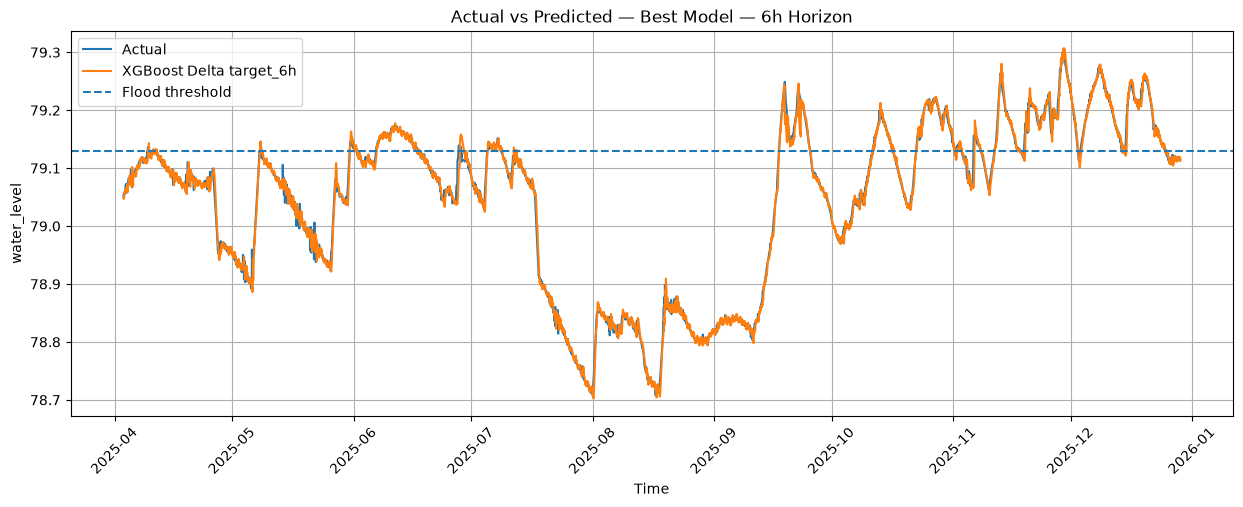

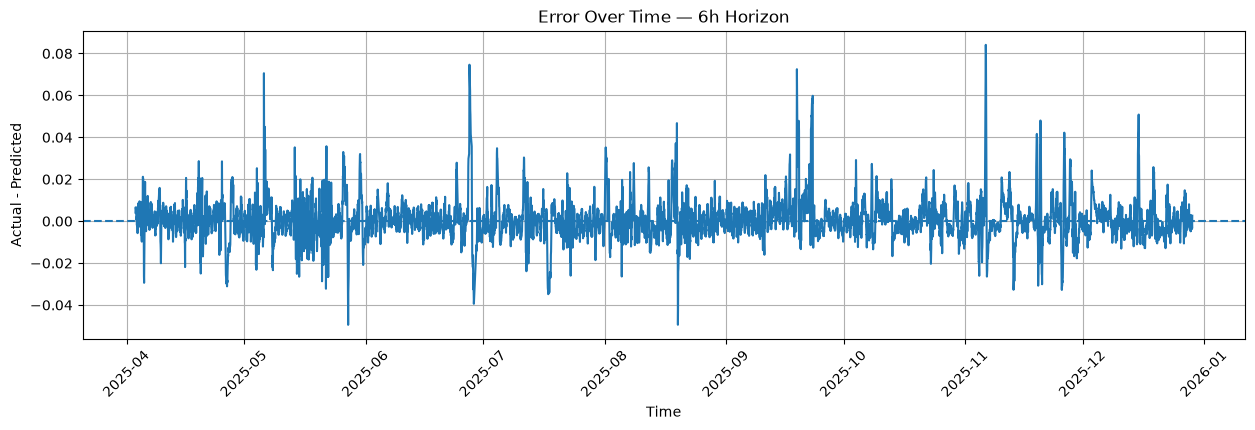

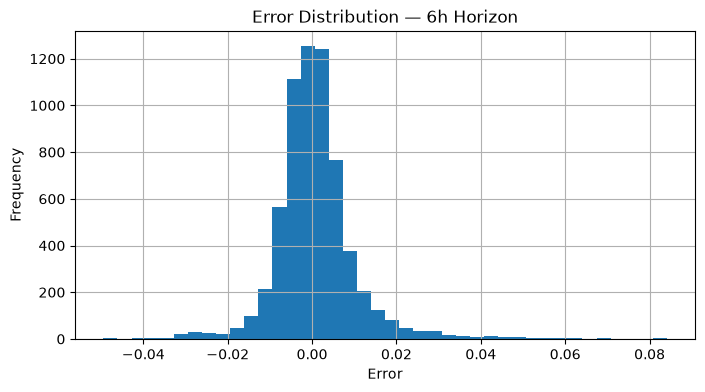

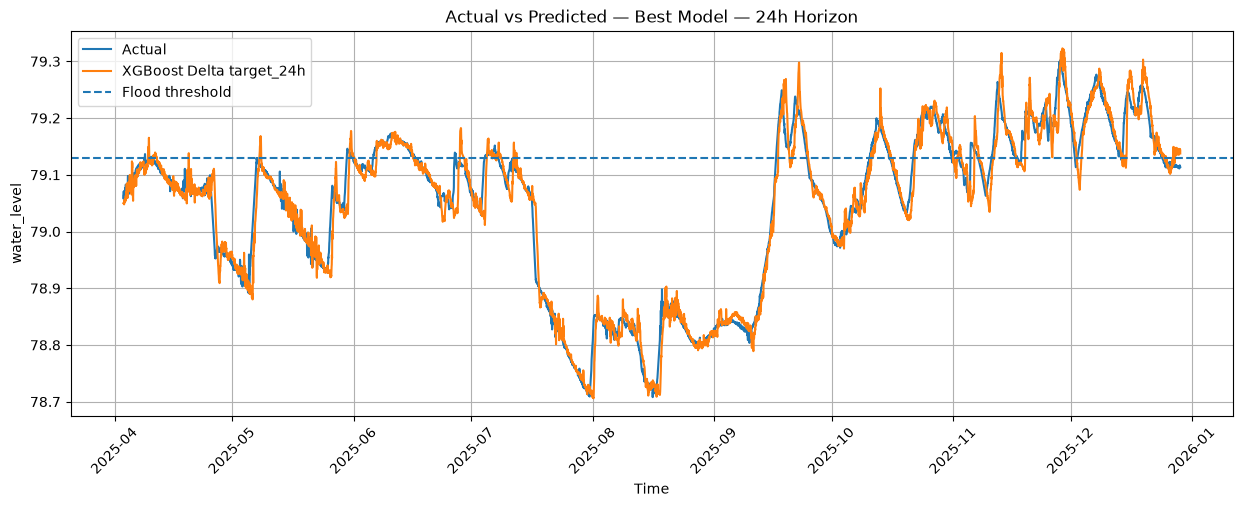

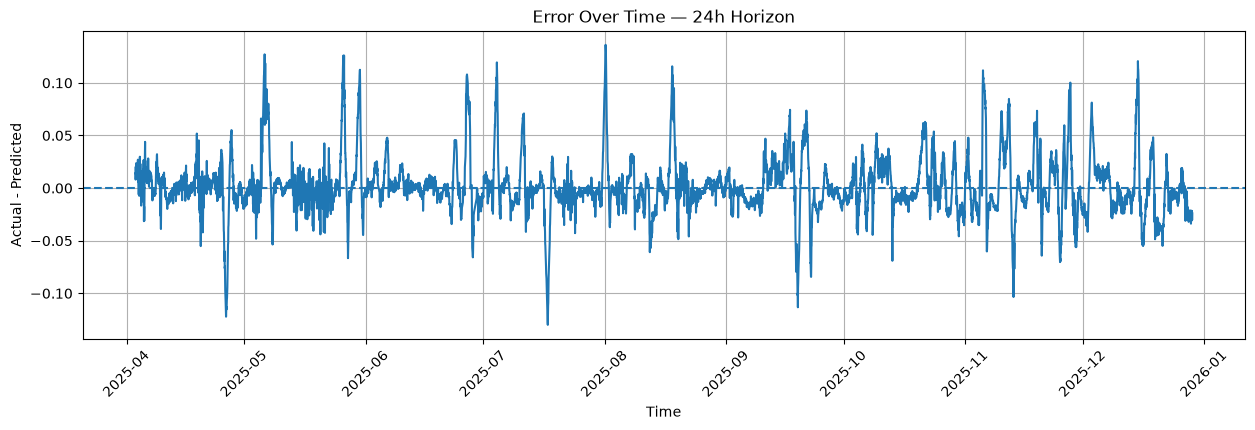

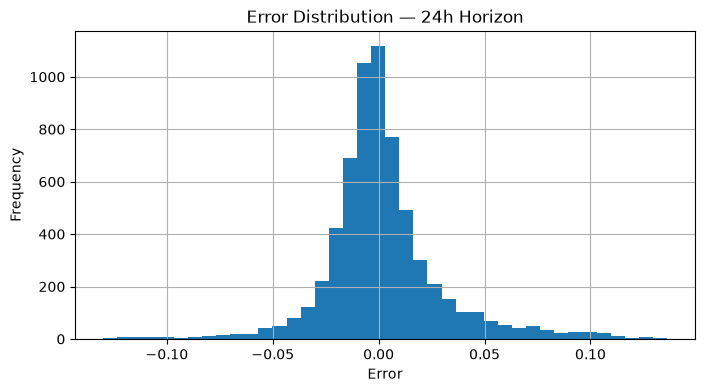

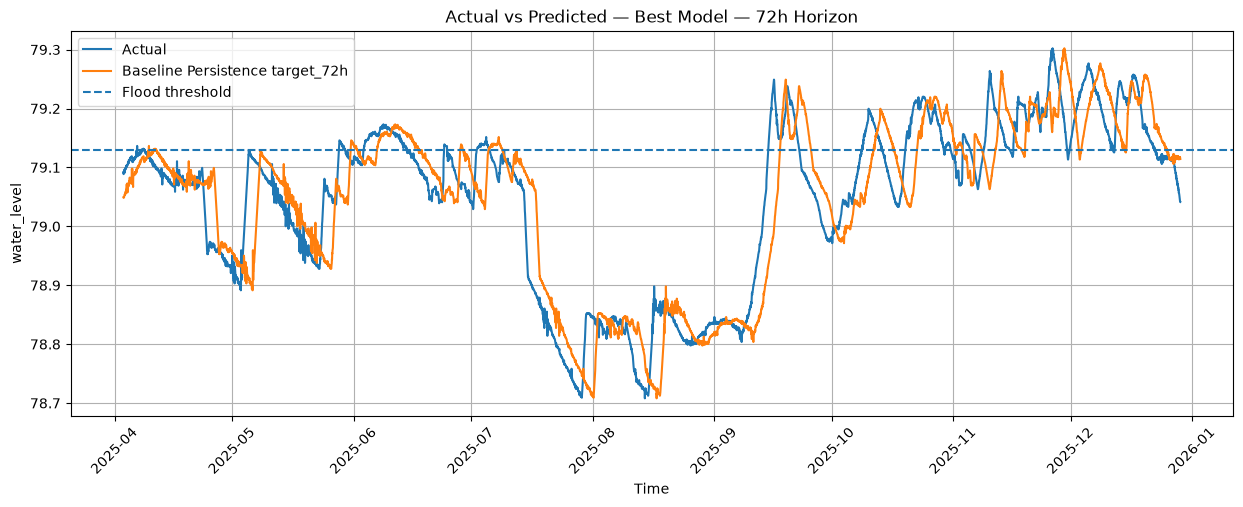

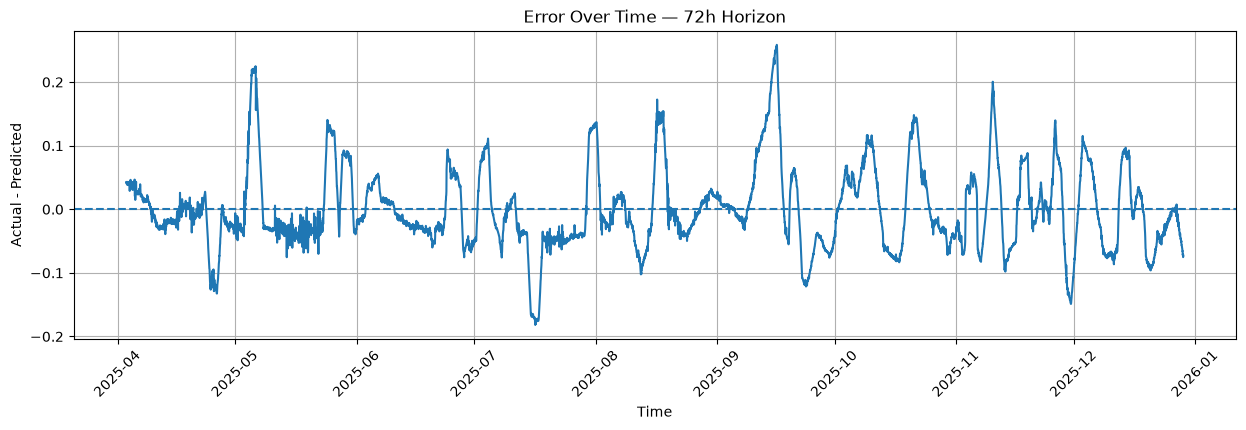

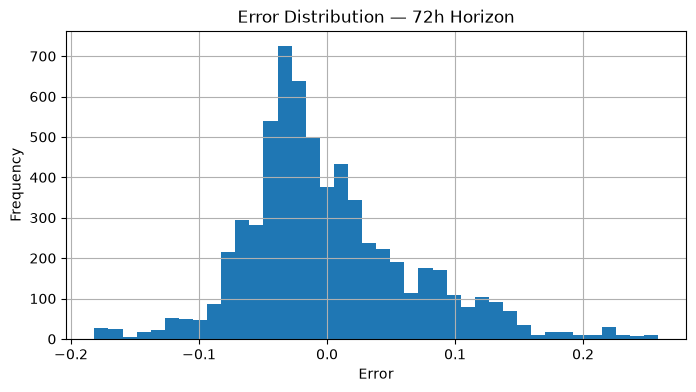

In [55]:
# ============================================================
# 14. Plot actual vs predicted for best model per horizon
# ============================================================

for h in HORIZONS:
    target = f"target_{h}h"

    if target not in test_sets:
        continue

    test = test_sets[target]
    best_row = best_models_df[best_models_df["horizon"] == target]

    if best_row.empty:
        continue

    best_model_name = best_row.iloc[0]["model"]
    y_true = test[target].to_numpy()
    y_pred = predictions[best_model_name]

    plt.figure(figsize=(15, 5))
    plt.plot(test[DATE_COL], y_true, label="Actual")
    plt.plot(test[DATE_COL], y_pred, label=best_model_name)
    plt.axhline(flood_thresholds[target], linestyle="--", label="Flood threshold")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.title(f"Actual vs Predicted — Best Model — {h}h Horizon")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    error = y_true - y_pred

    plt.figure(figsize=(15, 4))
    plt.plot(test[DATE_COL], error)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Actual - Predicted")
    plt.title(f"Error Over Time — {h}h Horizon")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(error, bins=40)
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.title(f"Error Distribution — {h}h Horizon")
    plt.grid(True)
    plt.show()

In [56]:
# ============================================================
# 15. Flood-risk classification reports for best models
# ============================================================

for h in HORIZONS:
    target = f"target_{h}h"

    if target not in test_sets:
        continue

    best_row = best_models_df[best_models_df["horizon"] == target]

    if best_row.empty:
        continue

    best_model_name = best_row.iloc[0]["model"]

    test = test_sets[target]
    threshold = flood_thresholds[target]

    y_true = test[target].to_numpy()
    y_pred = predictions[best_model_name]

    y_true_flood = (y_true >= threshold).astype(int)
    y_pred_flood = (y_pred >= threshold).astype(int)

    print("=" * 80)
    print(f"Flood-risk report: {h}h horizon")
    print("Best model:", best_model_name)
    print("Threshold:", threshold)
    print(classification_report(
        y_true_flood,
        y_pred_flood,
        target_names=["Non-flood", "Flood"],
        zero_division=0
    ))
    print("Confusion matrix:")
    print(confusion_matrix(y_true_flood, y_pred_flood))

Flood-risk report: 6h horizon
Best model: XGBoost Delta target_6h
Threshold: 79.13
              precision    recall  f1-score   support

   Non-flood       0.98      0.99      0.98      4369
       Flood       0.97      0.96      0.96      2026

    accuracy                           0.98      6395
   macro avg       0.97      0.97      0.97      6395
weighted avg       0.98      0.98      0.98      6395

Confusion matrix:
[[4306   63]
 [  91 1935]]
Flood-risk report: 24h horizon
Best model: XGBoost Delta target_24h
Threshold: 79.13
              precision    recall  f1-score   support

   Non-flood       0.94      0.95      0.95      4369
       Flood       0.90      0.86      0.88      2026

    accuracy                           0.93      6395
   macro avg       0.92      0.91      0.91      6395
weighted avg       0.93      0.93      0.93      6395

Confusion matrix:
[[4169  200]
 [ 275 1751]]
Flood-risk report: 72h horizon
Best model: Baseline Persistence target_72h
Threshold: 79

Top features for 6h model: XGBoost Delta target_6h


,feature,importance
0,reservoir_volume,0.069079
11,sin_month,0.063251
102,reservoir_volume_slope_72h,0.045221
101,reservoir_volume_change_72h,0.038574
97,reservoir_volume_change_24h,0.037785
42,water_level_roll_min_72h,0.028997
98,reservoir_volume_slope_24h,0.026173
63,reservoir_volume_lag_48h,0.025524
51,water_level_slope_12h,0.024076
18,water_level_lag_48h,0.023601


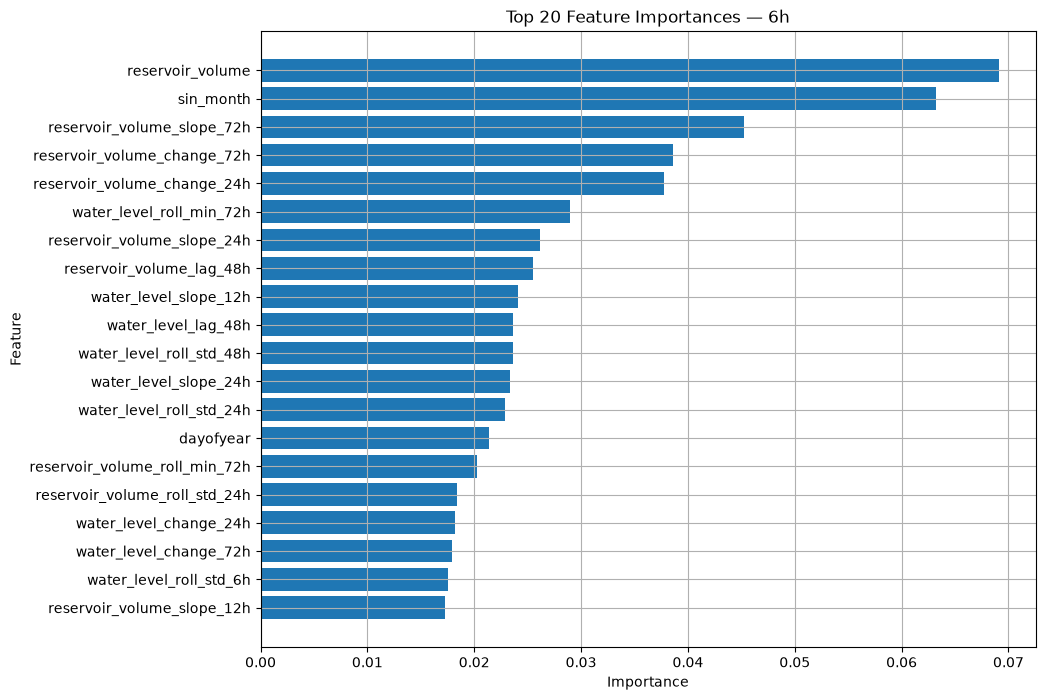

Saved: ../src/data/processed/feature_importance_all_features_6h.csv
Top features for 24h model: XGBoost Delta target_24h


,feature,importance
97,reservoir_volume_change_24h,0.086121
11,sin_month,0.077400
98,reservoir_volume_slope_24h,0.071076
52,water_level_change_24h,0.048394
53,water_level_slope_24h,0.041102
50,water_level_change_12h,0.031250
51,water_level_slope_12h,0.030816
95,reservoir_volume_change_12h,0.030438
96,reservoir_volume_slope_12h,0.021139
80,reservoir_volume_roll_max_24h,0.016169


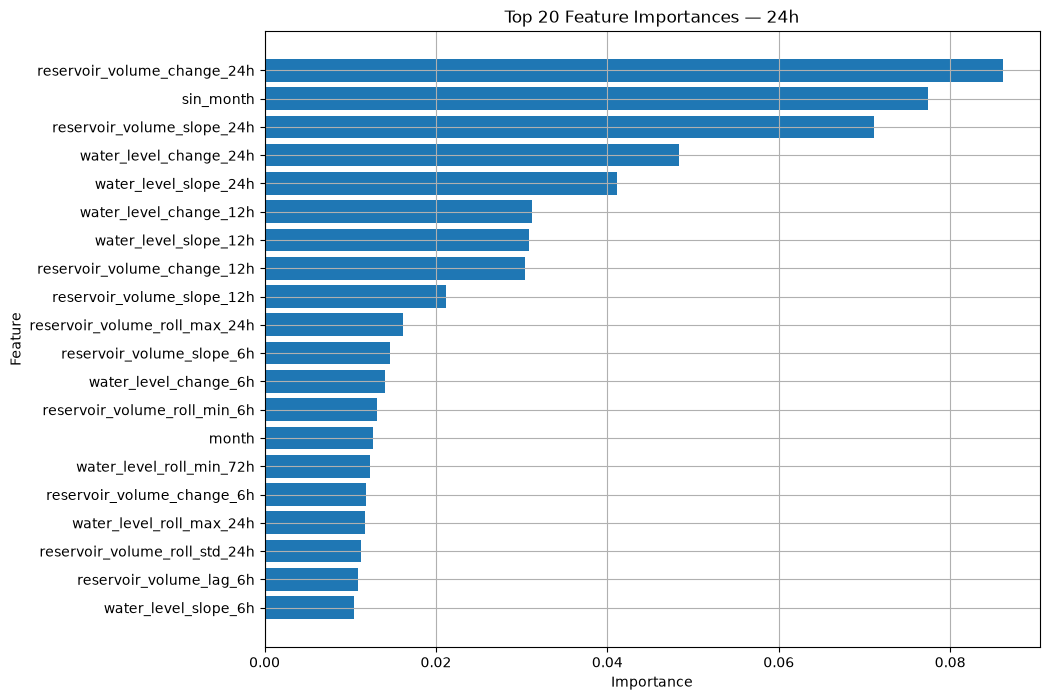

Saved: ../src/data/processed/feature_importance_all_features_24h.csv
Top features for 72h model: XGBoost Delta target_72h


,feature,importance
97,reservoir_volume_change_24h,0.062347
96,reservoir_volume_slope_12h,0.061375
95,reservoir_volume_change_12h,0.047098
98,reservoir_volume_slope_24h,0.035957
93,reservoir_volume_change_6h,0.024062
64,reservoir_volume_lag_72h,0.023714
94,reservoir_volume_slope_6h,0.023513
19,water_level_lag_72h,0.019111
51,water_level_slope_12h,0.018982
77,reservoir_volume_roll_mean_24h,0.017780


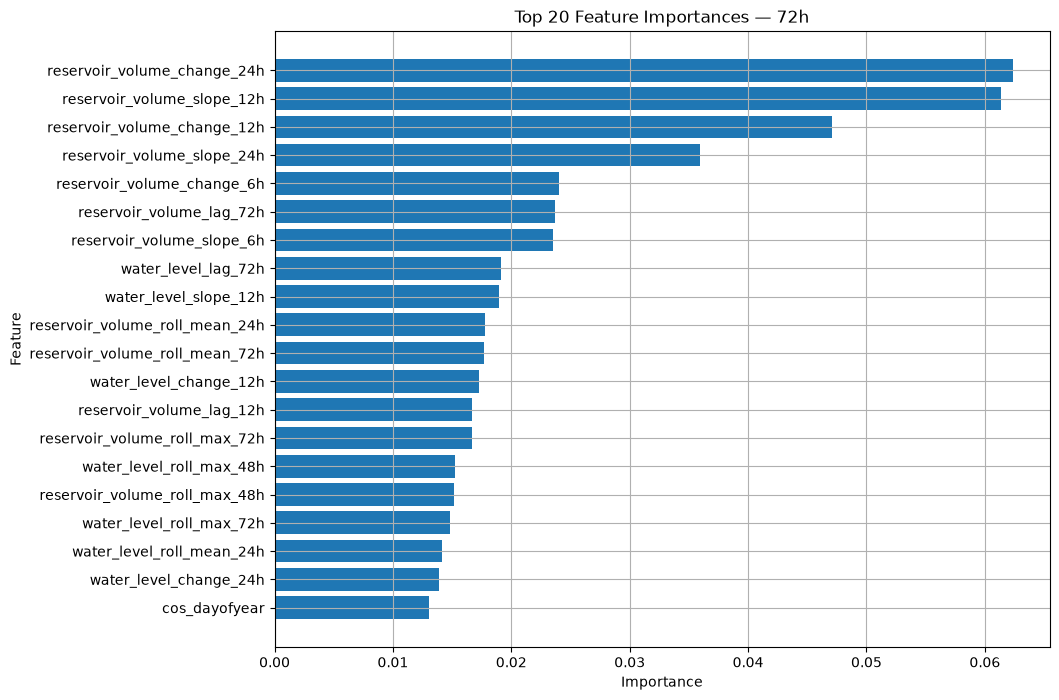

Saved: ../src/data/processed/feature_importance_all_features_72h.csv


In [57]:
# ============================================================
# 16. Feature importance for tree-based models
# ============================================================

importance_tables = {}

for h in HORIZONS:
    target = f"target_{h}h"

    candidate_names = [
        f"XGBoost Delta {target}",
        f"XGBoost Absolute {target}",
        f"HistGB Delta {target}",
        f"HistGB Absolute {target}",
    ]

    model_name = next((name for name in candidate_names if name in models), None)

    if model_name is None:
        print(f"No tree-based model found for {target}")
        continue

    model = models[model_name]

    if not hasattr(model, "feature_importances_"):
        print(f"Feature importance not available for {model_name}")
        continue

    importance_df = pd.DataFrame({
        "feature": FEATURES,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_tables[target] = importance_df

    print("=" * 80)
    print(f"Top features for {h}h model: {model_name}")
    display(importance_df.head(30))

    plt.figure(figsize=(10, 8))
    top = importance_df.head(20).iloc[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top 20 Feature Importances — {h}h")
    plt.grid(True)
    plt.show()

    imp_path = os.path.join(OUTPUT_DIR, f"feature_importance_all_features_{h}h.csv")
    importance_df.to_csv(imp_path, index=False)
    print("Saved:", imp_path)

In [58]:
# ============================================================
# 17. Build final forecast table with risk level
# ============================================================

# Use the 24h test set as main output if available; otherwise first available horizon.
main_target = "target_24h" if "target_24h" in test_sets else list(test_sets.keys())[0]
final_forecasts = test_sets[main_target][[DATE_COL, TARGET_COL]].copy()

if RESERVOIR_COL in test_sets[main_target].columns:
    final_forecasts[RESERVOIR_COL] = test_sets[main_target][RESERVOIR_COL].values

for h in HORIZONS:
    target = f"target_{h}h"

    if target not in test_sets:
        continue

    test = test_sets[target]
    best_row = best_models_df[best_models_df["horizon"] == target]

    if best_row.empty:
        continue

    best_model_name = best_row.iloc[0]["model"]

    # Align by timestamp.
    temp = test[[DATE_COL, target]].copy()
    temp[f"forecast_{h}h"] = predictions[best_model_name]
    temp[f"forecast_model_{h}h"] = best_model_name
    temp[f"error_{h}h"] = temp[target] - temp[f"forecast_{h}h"]

    final_forecasts = final_forecasts.merge(temp, on=DATE_COL, how="left")

# Risk thresholds from first/main train set approximation: use df_model chronological train section.
train_global, _, _ = time_split(df_model.dropna(subset=[TARGET_COL]).reset_index(drop=True))

level_high = train_global[TARGET_COL].quantile(0.90)
level_critical = train_global[TARGET_COL].quantile(0.97)

rise_col = f"{TARGET_COL}_change_24h"
if rise_col in train_global.columns:
    rise_high = train_global[rise_col].quantile(0.90)
    rise_critical = train_global[rise_col].quantile(0.97)
else:
    rise_high = 0
    rise_critical = 0

print("High level threshold:", level_high)
print("Critical level threshold:", level_critical)
print("High rise threshold:", rise_high)
print("Critical rise threshold:", rise_critical)


def assign_risk(row):
    forecast_col = "forecast_24h" if "forecast_24h" in row.index and pd.notna(row.get("forecast_24h")) else None

    if forecast_col is None:
        available = [c for c in row.index if c.startswith("forecast_") and c.endswith("h")]
        forecast_col = available[0] if available else None

    if forecast_col is None or pd.isna(row[forecast_col]):
        return "Unknown"

    predicted_level = row[forecast_col]
    predicted_rise = predicted_level - row[TARGET_COL]

    if predicted_level >= level_critical or predicted_rise >= rise_critical:
        return "Critical"

    if predicted_level >= level_high or predicted_rise >= rise_high:
        return "High"

    if predicted_rise > 0:
        return "Medium"

    return "Low"


final_forecasts["risk_level"] = final_forecasts.apply(assign_risk, axis=1)

display(final_forecasts.head())
display(final_forecasts["risk_level"].value_counts())

High level threshold: 79.13249
Critical level threshold: 79.24008620000001
High rise threshold: 0.036216000000008804
Critical rise threshold: 0.08875000000000455


,timestamp,water_level,reservoir_volume,target_6h,forecast_6h,forecast_model_6h,error_6h,target_24h,forecast_24h,forecast_model_24h,error_24h,target_72h,forecast_72h,forecast_model_72h,error_72h,risk_level
0,2025-04-03 06:00:00+00:00,79.04925,8.391027,79.05225,79.048158,XGBoost Delta target_6h,0.004092,79.06924,79.049785,XGBoost Delta target_24h,0.019455,79.09212,79.04925,Baseline Persistence target_72h,0.04287,Medium
1,2025-04-03 07:00:00+00:00,79.04837,8.380487,79.05363,79.047038,XGBoost Delta target_6h,0.006592,79.05762,79.049559,XGBoost Delta target_24h,0.008061,79.08862,79.04837,Baseline Persistence target_72h,0.04025,Medium
2,2025-04-03 08:00:00+00:00,79.04900,8.388041,79.05350,79.047265,XGBoost Delta target_6h,0.006235,79.06413,79.049286,XGBoost Delta target_24h,0.014844,79.09188,79.04900,Baseline Persistence target_72h,0.04288,Medium
3,2025-04-03 09:00:00+00:00,79.04975,8.397047,79.05525,79.049351,XGBoost Delta target_6h,0.005899,79.06463,79.051610,XGBoost Delta target_24h,0.013020,79.09062,79.04975,Baseline Persistence target_72h,0.04087,Medium
4,2025-04-03 10:00:00+00:00,79.04951,8.394049,79.05388,79.049227,XGBoost Delta target_6h,0.004653,79.07150,79.047892,XGBoost Delta target_24h,0.023608,79.09225,79.04951,Baseline Persistence target_72h,0.04274,Low


risk_level
Low         3199
High        1769
Medium      1166
Critical     261
Name: count, dtype: int64

In [59]:
# ============================================================
# 18. Save forecasts, results, and models
# ============================================================

forecast_path = os.path.join(OUTPUT_DIR, "final_forecasts_with_risk_all_features.csv")
final_forecasts.to_csv(forecast_path, index=False)
print("Saved forecasts:", forecast_path)

results_path = os.path.join(OUTPUT_DIR, "forecast_results_all_features.csv")
results_df.to_csv(results_path, index=False)
print("Saved results:", results_path)

best_path = os.path.join(OUTPUT_DIR, "best_models_all_features.csv")
best_models_df.to_csv(best_path, index=False)
print("Saved best model summary:", best_path)

for name, model in models.items():
    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace(":", "")
    )
    model_path = os.path.join(MODEL_DIR, f"{safe_name}.joblib")
    joblib.dump(model, model_path)

print("Saved models to:", MODEL_DIR)

Saved forecasts: ../src/data/processed/final_forecasts_with_risk_all_features.csv
Saved results: ../src/data/processed/forecast_results_all_features.csv
Saved best model summary: ../src/data/processed/best_models_all_features.csv
Saved models to: ../models


## How to explain this notebook

This version uses reservoir volume as an additional hydrological state variable. The model still predicts future `water_level`, but it learns from both:

- recent water-level behaviour
- recent reservoir-volume behaviour
- seasonal and daily time patterns

The notebook also converts real forecast horizons into row shifts using the detected timestamp interval. This avoids the earlier bug where `6h` could accidentally mean 6 rows instead of 6 real hours.